In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

!pip install neuraloperator

from neuralop.models import FNO # pip install neuraloperator


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 6.6 MB/s eta 0:00:00


In [2]:

# прямой оператор

class heat_operator:
    def __init__(self, a, T, x):
        self.a = a
        self.T = T
        self.x = x

    def __call__(self, u):
        return self.heat_forward(u, self.a, self.T, self.x)

    def heat_forward(self, u0, a, T, x):
        dx = x[1] - x[0]
        N = len(x)

        k = np.fft.rfftfreq(N, d=dx) * 2 * np.pi

        u_hat = np.fft.rfft(u0)
        G_hat = np.exp(- (a**2) * (k**2) * T)
        y_hat = G_hat * u_hat

        return np.fft.irfft(y_hat, n=N)



In [3]:

@dataclass
class Config:
    # Параметры генерации данных
    num_samples: int = 5000
    num_points: int = 256
    l_max: float = 10.0
    t_min: float = 0.1
    t_max: float = 2.0
    a_coeff: float = 1.0

    # Обучение
    batch_size: int = 64
    test_split: float = 0.2
    lr: float = 1e-3
    weight_decay: float = 1e-4
    epochs: int = 50

    # FNO Архитектура
    n_modes: tuple = (20,)
    hidden_channels: int = 64
    in_channels: int = 2   # phi(x), x, T
    out_channels: int = 1  # u0(x)

    device: torch.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
def generate_dataset(num_samples, num_points, L_max, T_min, T_max, a=1.0):
    """
    Генерирует пары (u0, phi) для обратной задачи теплопроводности.
    Использует БПФ, чтобы описать оператор A_T.
    """
    # Пространственная сетка [-L_max, L_max)
    x = np.linspace(-L_max, L_max, num_points, endpoint=False)
    dx = x[1] - x[0]

    # Волновые числа для БПФ
    k = np.fft.rfftfreq(num_points, d=dx) * 2 * np.pi

    u0_list = []
    phi_list = []
    T_list = []

    for _ in range(num_samples):
        # Генерация u0(x)

        u0 = np.full(num_points, 0.0)

        # Пока u0 это 1 функция вида гауссианы
        num_components = np.random.randint(1, 3)
        for _ in range(num_components):
            A = np.random.uniform(1, 5)
            w = np.random.uniform(0.1, 1.0)
            x0 = np.random.uniform(3.0, 7.0)
            # Функция вида A * exp(-w*x**2) удовлетворяет условиям
            u0 += A * np.exp(-w * (np.abs(x) - x0)**2)

        # Генерация случайного финального момента времени T
        T = np.random.uniform(T_min, T_max)

        phi = heat_operator(a, T, x)(u0)

        u0_list.append(u0)
        phi_list.append(phi)
        T_list.append(T)

    return torch.tensor(np.array(u0_list), dtype=torch.float32), \
           torch.tensor(np.array(phi_list), dtype=torch.float32), \
           torch.tensor(np.array(T_list), dtype=torch.float32), \
           torch.tensor(x, dtype=torch.float32)

def prepare_dataloaders(cfg : Config):
    print("Генерация обучающей выборки")
    u0_data, phi_data, T_data, x_grid = generate_dataset(
        cfg.num_samples, cfg.num_points, cfg.l_max, cfg.t_min, cfg.t_max, cfg.a_coeff
    )

    # Подготовка входа для FNO. Добавляется параметр T как дополнительный канал
    T_expanded = T_data.unsqueeze(1).repeat(1, cfg.num_points)

    # input_tensor имеет размерность: (Batch, 2 channels, Num_points)
    # Первый канал это phi(x), а второй T, каждый имеет Num_points значений
    input_tensor = torch.stack([phi_data, T_expanded], dim=1) # (Batch, 2, Num_points)
    target_tensor = u0_data.unsqueeze(1) # Выход: (Batch, Num_points, 1)

    # Разбиение на train/test
    train_size = int((1.0 - cfg.test_split) * cfg.num_samples)
    train_dataset = TensorDataset(input_tensor[:train_size], target_tensor[:train_size])
    test_dataset = TensorDataset(input_tensor[train_size:], target_tensor[train_size:])

    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False)

    return train_loader, test_loader, x_grid, input_tensor, target_tensor, train_size

In [5]:
def create_model(cfg: Config):
    return FNO(
        n_modes=cfg.n_modes,
        hidden_channels=cfg.hidden_channels,
        in_channels=cfg.in_channels,
        out_channels=cfg.out_channels
    ).to(cfg.device)


def train_fno(model, train_loader, test_loader, cfg: Config):
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)
    criterion = nn.MSELoss()

    print("Старт обучения")

    for epoch in range(cfg.epochs):
        model.train()
        train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(cfg.device), batch_y.to(cfg.device)
            optimizer.zero_grad()
            out = model(batch_x)
            loss = criterion(out, batch_y)
            loss.backward()
            optimizer.step()
            assert out.shape == batch_y.shape, f"Mismatch: {out.shape} vs {batch_y.shape}"
            train_loss += loss.item()

        scheduler.step()

        if (epoch + 1) % 10 == 0:
            model.eval()
            test_loss = 0.0
            with torch.no_grad():
                for batch_x, batch_y in test_loader:
                    out = model(batch_x.to(cfg.device))
                    test_loss += criterion(out, batch_y.to(cfg.device)).item()
            print(f"Epoch {epoch+1:02d}, Train Loss: {train_loss/len(train_loader):.6f}, Test Loss: {test_loss/len(test_loader):.6f}")

    return model


In [6]:
cfg = Config()
print(f"Используется устройство: {cfg.device}")

# Подготовка тренировочных данных
train_loader, test_loader, x_grid, input_tensor, target_tensor, train_size = prepare_dataloaders(
    cfg)

Используется устройство: cuda
Генерация обучающей выборки...


In [7]:
# Обучение модели
model = create_model(cfg)
model = train_fno(model, train_loader, test_loader, cfg)

Старт обучения
Epoch 10, Train Loss: 0.002722, Test Loss: 0.002482
Epoch 20, Train Loss: 0.001455, Test Loss: 0.001861
Epoch 30, Train Loss: 0.000953, Test Loss: 0.000802
Epoch 40, Train Loss: 0.000587, Test Loss: 0.000594
Epoch 50, Train Loss: 0.000535, Test Loss: 0.000559


In [8]:
# Прогноз модели
model.eval()
with torch.no_grad():
    sample_idx = 2
    test_input = input_tensor[train_size +
                              sample_idx:train_size + sample_idx + 1].to(cfg.device)
    true_u0 = target_tensor[train_size + sample_idx].numpy()
    pred_u0 = model(test_input).cpu().numpy()[0]
    phi_vis = test_input[0, 0, :].cpu().numpy()
    T_val = test_input[0, 1, 0].item()



/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

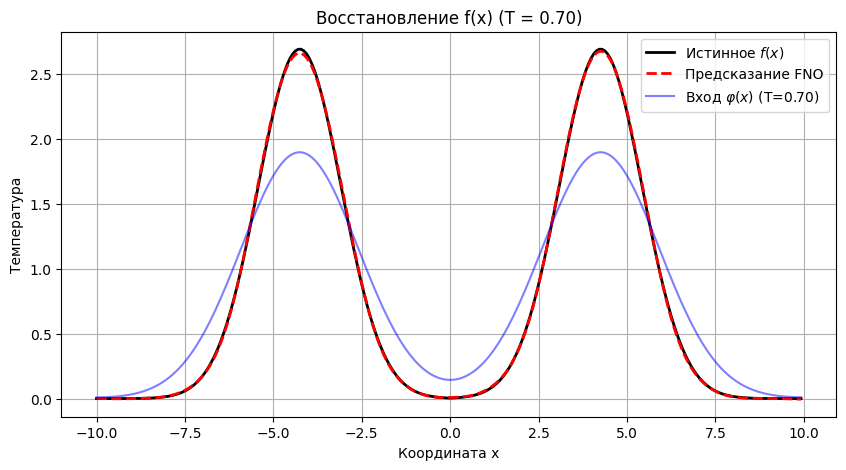

In [9]:
 # Визуализация результата

plt.figure(figsize=(10, 5))
plt.plot(x_grid.numpy(), true_u0.reshape(-1), label='Истинное $f(x)$', color='black', linewidth=2)
plt.plot(x_grid.numpy(), pred_u0.reshape(-1), label='Предсказание FNO', color='red', linestyle='dashed', linewidth=2)
plt.plot(x_grid.numpy(), phi_vis, label=f'Вход $\\varphi(x)$ (T={T_val:.2f})', color='blue', alpha=0.5)
plt.title(f"Восстановление f(x) (T = {T_val:.2f})")
plt.xlabel("Координата x")
plt.ylabel("Температура")
plt.legend()
plt.grid(True)
plt.show()

In [44]:
def f(x):

  return  2 * np.exp(-0.4 *(np.abs(x) - 3)**2) +  3 * np.exp(-0.5 *(np.abs(x) - 6)**2)



In [11]:
def generate_test(num_points, L_max, T, a=1.0):
    """
    Генерирует пары (u0, phi) для обратной задачи теплопроводности.
    Использует БПФ, чтобы описать оператор A_T.
    """
    # Пространственная сетка [-L_max, L_max)
    x = np.linspace(-L_max, L_max, num_points, endpoint=False)
    dx = x[1] - x[0]

    # Волновые числа для БПФ
    k = np.fft.rfftfreq(num_points, d=dx) * 2 * np.pi

    u0_list = []
    phi_list = []
    T_list = []

    u0 = f(x)

    phi = heat_operator(a, T, x)(u0)

    u0_list.append(u0)
    phi_list.append(phi)
    T_list.append(T)

    return torch.tensor(np.array(u0_list), dtype=torch.float32), \
           torch.tensor(np.array(phi_list), dtype=torch.float32), \
           torch.tensor(np.array(T_list), dtype=torch.float32), \
           torch.tensor(x, dtype=torch.float32)

def prepare_dataloaders_test(cfg : Config, T):
    u0_data, phi_data, T_data, x_grid = generate_test(cfg.num_points, cfg.l_max, T = T)

    # Подготовка входа для FNO. Добавляется параметр T как дополнительный канал
    T_expanded = T_data.unsqueeze(1).repeat(1, cfg.num_points)

    # input_tensor имеет размерность: (Batch, 2 channels, Num_points)
    # Первый канал это phi(x), а второй T, каждый имеет Num_points значений
    input_tensor = torch.stack([phi_data, T_expanded], dim=1) # (Batch, 2, Num_points)
    #target_tensor = u0_data.unsqueeze(1) # Выход: (Batch, Num_points, 1)

    return x_grid, input_tensor

In [46]:
T = 1.5
model.eval()
with torch.no_grad():
    x_grid, test_input  = prepare_dataloaders_test(cfg, T)
    test_input = test_input.to(cfg.device)
    true_u0 = f(x_grid)
    pred_u0 = model(test_input).cpu().numpy()[0]
    phi_vis = test_input[0, 0, :].cpu().numpy()
    T_val = test_input[0, 1, 0].item()

/tmp/ipykernel_2390/2869458881.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return  3 * np.exp(-0.5 *(np.abs(x) - 6)**2)


/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.13/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


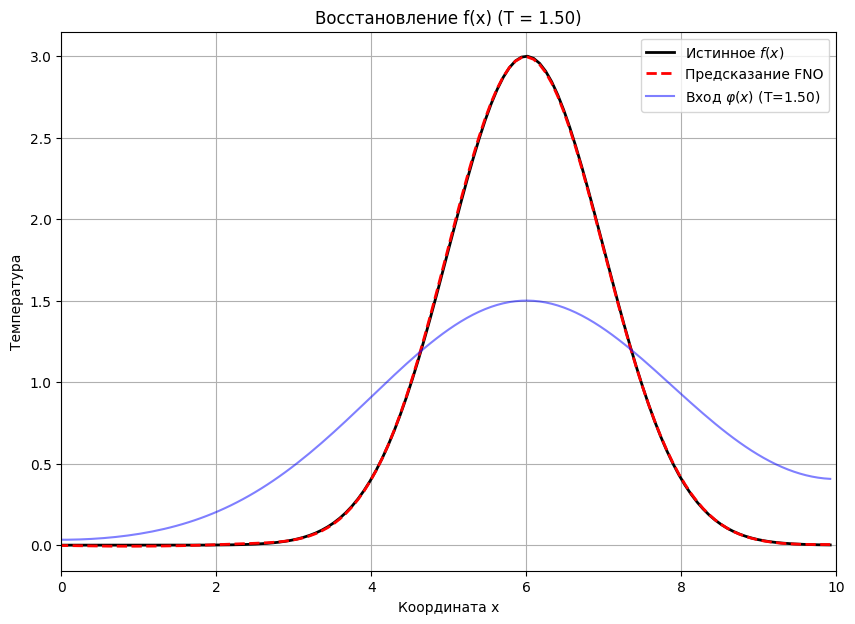

In [49]:
plt.figure(figsize=(10, 7))
plt.plot(x_grid.numpy(), true_u0, label='Истинное $f(x)$', color='black', linewidth=2)
plt.plot(x_grid.numpy(), pred_u0.reshape(-1), label='Предсказание FNO', color='red', linestyle='dashed', linewidth=2)
plt.plot(x_grid.numpy(), phi_vis, label=f'Вход $\\varphi(x)$ (T={T_val:.2f})', color='blue', alpha=0.5)
plt.xlim((0, 10))
plt.title(f"Восстановление f(x) (T = {T_val:.2f})")
plt.xlabel("Координата x")
plt.ylabel("Температура")
plt.legend()
plt.grid(True)
plt.savefig('experiment_fx2.pdf', format='pdf', bbox_inches='tight')

# 2. Только после этого отображаем (если нужно)
plt.show()